## Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

## Loading env variables

In [2]:
load_dotenv()

True

## Define LLM

In [3]:
model = ChatOpenAI()

## Define State

In [11]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

## Creating Nodes

In [12]:

def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [13]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

## Define and Compile Graph

In [15]:

graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

## Execute the Graph

In [16]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "I. Introduction\n    A. Brief overview of what AI is\n    B. Explanation of why AI is becoming increasingly important in India\n    C. Thesis statement - The rise of AI in India and its implications\n\nII. Historical perspective of AI in India\n    A. Early adoption of AI technology in India\n    B. Key milestones in the development of AI in India\n    C. Comparison with other countries' AI development\n\nIII. Current state of AI in India\n    A. Growth of AI startups in India\n    B. Government initiatives to promote AI technology\n    C. Adoption of AI in various industries in India\n\nIV. Opportunities and challenges of AI in India\n    A. Job creation potential of AI in India\n    B. Impact of AI on traditional industries in India\n    C. Potential ethical concerns related to AI in India\n\nV. Future outlook for AI in India\n    A. Predictions for the growth of AI technology in India\n    B. Potential areas for future development of AI i

In [17]:
print(final_state['outline'])

I. Introduction
    A. Brief overview of what AI is
    B. Explanation of why AI is becoming increasingly important in India
    C. Thesis statement - The rise of AI in India and its implications

II. Historical perspective of AI in India
    A. Early adoption of AI technology in India
    B. Key milestones in the development of AI in India
    C. Comparison with other countries' AI development

III. Current state of AI in India
    A. Growth of AI startups in India
    B. Government initiatives to promote AI technology
    C. Adoption of AI in various industries in India

IV. Opportunities and challenges of AI in India
    A. Job creation potential of AI in India
    B. Impact of AI on traditional industries in India
    C. Potential ethical concerns related to AI in India

V. Future outlook for AI in India
    A. Predictions for the growth of AI technology in India
    B. Potential areas for future development of AI in India
    C. Role of AI in shaping India's future economy and soc

In [18]:
print(final_state['content'])



I. Introduction

A. Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and act like humans. This technology involves the development of algorithms that allow computers to perform tasks such as speech recognition, decision-making, and problem-solving. 

B. AI is becoming increasingly important in India due to its potential to drive innovation, improve efficiency, and enhance productivity across various industries. With the advent of new technologies such as machine learning and deep learning, AI has the power to revolutionize the way businesses operate and transform the way we live and work.

C. Thesis statement - The rise of AI in India holds great promise for the country's economic growth and societal development, but it also presents challenges in terms of job displacement, ethical concerns, and the need for continuous upskilling and reskilling of the workforce.

II. Historical perspective of AI in India

A. India ha

## Visualize Graph

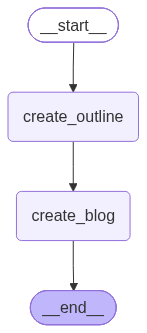

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())